In [1]:
from pynq import Overlay, allocate
import numpy as np

# 1. Load the new hardware design
overlay = Overlay("mac.bit")
dma = overlay.axi_dma_0

# 2. Allocate contiguous memory buffers for the DMA
in_buffer = allocate(shape=(784,), dtype=np.uint32)
# Using int32 for the output buffer so Python prints negative numbers correctly
out_buffer = allocate(shape=(1,), dtype=np.int32) 

# 3. Create an array of 784 zeros to test the comparator fix
pixels = np.random.randint(0, 256, size=(784,), dtype=np.uint32)
np.copyto(in_buffer, pixels)

# 4. Trigger the hardware computation
# ALWAYS start the receive channel before the send channel
dma.recvchannel.transfer(out_buffer)  
dma.sendchannel.transfer(in_buffer)   

# 5. Wait for computation to finish
dma.sendchannel.wait()
dma.recvchannel.wait()

print(f"Final Hardware Accumulated Result: {out_buffer[0]}")

Final Hardware Accumulated Result: -2025


In [2]:
#pixels = np.random.randint(0, 256, size=(784,), dtype=np.uint32) 
pixels = np.zeros((784,), dtype=np.uint32)
np.copyto(in_buffer, pixels)

# 4. Trigger the hardware computation
# ALWAYS start the receive channel before the send channel
dma.recvchannel.transfer(out_buffer)  
dma.sendchannel.transfer(in_buffer)   

# 5. Wait for computation to finish
dma.sendchannel.wait()
dma.recvchannel.wait()

print(f"Final Hardware Accumulated Result: {out_buffer[0]}")

Final Hardware Accumulated Result: 0


In [5]:
# 2. Allocate contiguous memory buffers for the DMA
in_buffer = allocate(shape=(784,), dtype=np.uint32)
out_buffer = allocate(shape=(1,), dtype=np.int32) 

# 3. Create an array of 784 pixels, all set to 255
# Using np.full instead of np.zeros
pixels = np.full((784,), 255, dtype=np.uint32)
np.copyto(in_buffer, pixels)

# 4. Trigger the hardware computation
# ALWAYS start the receive channel before the send channel
dma.recvchannel.transfer(out_buffer)  
dma.sendchannel.transfer(in_buffer)   

# 5. Wait for computation to finish
dma.sendchannel.wait()
dma.recvchannel.wait()

print(f"Final Hardware Accumulated Result: {out_buffer[0]}")

Final Hardware Accumulated Result: -3414


In [6]:
# 1. Load the current hardware design
overlay = Overlay("lif.bit")
dma = overlay.axi_dma_0

BATCHES = 10
PIXELS_PER_BATCH = 784

# 2. Allocate a SMALLER input buffer (just for 1 batch)
in_buffer = allocate(shape=(PIXELS_PER_BATCH,), dtype=np.uint32)
out_buffer = allocate(shape=(1,), dtype=np.int32) 

# 3. Fill the single batch with zeros
pixels = np.full((784,), 255, dtype=np.uint32)
np.copyto(in_buffer, pixels)

print(f"Sending {BATCHES} batches to hardware...")

# 4. Start the receiver (it will wait until the hardware finishes all 10 batches)
dma.recvchannel.transfer(out_buffer)  

# 5. Send the data in 10 smaller chunks!
for i in range(BATCHES):
    dma.sendchannel.transfer(in_buffer)
    dma.sendchannel.wait() # Wait for this specific chunk to finish sending

# 6. Wait for the final computation to finish and be received
dma.recvchannel.wait()

print(f"Final Neuron Potential: {out_buffer[0]}")

Sending 10 batches to hardware...
Final Neuron Potential: -20124


In [7]:
# 1. Load the new hardware design
overlay = Overlay("neuron.bit")
dma = overlay.axi_dma_0

# 2. We are now processing exactly 8 timestamps
TIMESTAMPS = 8
PIXELS_PER_BATCH = 784

# 3. Allocate a SMALLER input buffer (just for 1 batch = 3136 bytes)
in_buffer = allocate(shape=(PIXELS_PER_BATCH,), dtype=np.uint32)
# Still 1 final output containing the 8-bit spike train
out_buffer = allocate(shape=(1,), dtype=np.uint32)

# 4. Generate some input data (1 batch of 255s)
pixels = np.full((PIXELS_PER_BATCH,), 255, dtype=np.uint32)
np.copyto(in_buffer, pixels)

# 5. Trigger the hardware computation
print(f"Sending {TIMESTAMPS} timestamps of data to the LIF Neuron in chunks...")

# ALWAYS Start the receiver FIRST. It will patiently wait until all 8 timestamps are processed.
dma.recvchannel.transfer(out_buffer)  

# Send the data in 8 smaller chunks to bypass the 16384 byte DMA limit!
for i in range(TIMESTAMPS):
    dma.sendchannel.transfer(in_buffer)
    dma.sendchannel.wait() # Wait for this specific batch to finish sending

# Wait for the final 8-bit spike train to be received
dma.recvchannel.wait()

# 6. Read the 8-bit Spike Train
spike_train_int = out_buffer[0]
# Format as an 8-bit binary string (e.g., "01001011")
spike_train_bin = format(spike_train_int, '08b')

print("\n=== SNN RESULTS ===")
print(f"Spike Train (Binary) : {spike_train_bin}")

# A little loop to tell you exactly which timestamps fired
print("\nSpike Breakdown:")
for i in range(8):
    # We read from left (oldest) to right (newest)
    spike = spike_train_bin[i]
    if spike == '1':
        print(f"  ⚡ Timestep {i}: SPIKE!")
    else:
        print(f"  - Timestep {i}: No spike.")

Sending 8 timestamps of data to the LIF Neuron in chunks...

=== SNN RESULTS ===
Spike Train (Binary) : 00000000

Spike Breakdown:
  - Timestep 0: No spike.
  - Timestep 1: No spike.
  - Timestep 2: No spike.
  - Timestep 3: No spike.
  - Timestep 4: No spike.
  - Timestep 5: No spike.
  - Timestep 6: No spike.
  - Timestep 7: No spike.


In [8]:
# Load bitstream
ol  = Overlay("layer.bit")
dma = ol.axi_dma_0

def predict(image):
    # image: (784,) uint8 numpy array

    send_buf = allocate(shape=(784,),  dtype=np.uint32)
    recv_buf = allocate(shape=(10,),   dtype=np.uint32)

    send_buf[:] = image.flatten().astype(np.uint32)

    # Send same image 8 times (8 timestamps)
    for ts in range(8):
        if ts == 7:
            dma.recvchannel.transfer(recv_buf)   # arm receive on last timestamp
        dma.sendchannel.transfer(send_buf)
        dma.sendchannel.wait()

    dma.recvchannel.wait()

    # Count spikes per neuron (lower 8 bits of each word)
    spike_counts = [bin(int(r) & 0xFF).count('1') for r in recv_buf]

    send_buf.freebuffer()
    recv_buf.freebuffer()

    return np.argmax(spike_counts), spike_counts


# --- Test ---
image = np.random.randint(0, 256, 784, dtype=np.uint8)
pred, counts = predict(image)
print("Predicted digit:", pred)
print("Spike counts:   ", counts)

Predicted digit: 0
Spike counts:    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


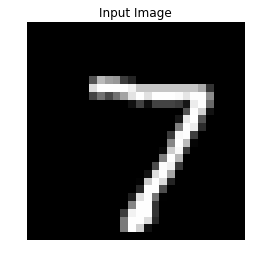

Spike counts: [0, 0, 0, 0, 0, 0, 0, 3, 0, 0]
Predicted digit: 7


In [9]:
%matplotlib inline
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

# ── Raw pixel values ──────────────────────────────────────────────────────────
pixels = [
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,84,185,159,151,60,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,222,254,254,254,254,241,198,198,198,198,198,198,198,198,170,52,0,0,0,0,
    0,0,0,0,0,0,0,0,67,114,72,114,163,227,254,225,254,254,254,250,229,254,254,140,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,17,66,14,67,67,67,59,21,236,254,106,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83,253,209,18,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,233,255,83,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,129,254,238,44,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,249,254,62,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,254,187,5,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,205,248,58,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,126,254,182,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,75,251,240,57,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,221,254,166,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,203,254,219,35,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,38,254,254,77,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,31,224,254,115,1,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,133,254,254,52,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,61,242,254,254,52,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,121,254,254,219,40,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,121,254,207,18,0,0,0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

image = np.array(pixels, dtype=np.uint8).reshape(28, 28)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

# ── Send to PL ────────────────────────────────────────────────────────────────
ol  = Overlay("layer.bit")
dma = ol.axi_dma_0

send_buf = allocate(shape=(784,), dtype=np.uint32)
recv_buf = allocate(shape=(10,),  dtype=np.uint32)

send_buf[:] = image.flatten().astype(np.uint32)

for ts in range(8):
    if ts == 7:
        dma.recvchannel.transfer(recv_buf)
    dma.sendchannel.transfer(send_buf)
    dma.sendchannel.wait()

dma.recvchannel.wait()

spike_counts = [bin(int(r) & 0xFF).count('1') for r in recv_buf]
predicted    = np.argmax(spike_counts)

print("Spike counts:", spike_counts)
print("Predicted digit:", predicted)

send_buf.freebuffer()
recv_buf.freebuffer()

In [2]:
#Testing for 500 Images 

In [ ]:
%matplotlib inline
from pynq import Overlay, allocate
import numpy as np
import os

# ── 1. Load Images from Folder ────────────────────────────────────────────────
folder_path = "mnist_500_quantized"
file_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])

images = []
true_labels = []

print(f"Loading {len(file_list)} images from '{folder_path}'...")

for filename in file_list:
    label_str = filename.split('_lbl_')[1].replace('.txt', '')
    true_labels.append(int(label_str))
    
    file_path = os.path.join(folder_path, filename)
    arr = np.loadtxt(file_path, dtype=np.uint8)
    
    if arr.size < 784:
        arr = np.pad(arr, (0, 784 - arr.size), 'constant')
    elif arr.size > 784:
        arr = arr[:784]
        
    images.append(arr.reshape(28, 28))

# ── 2. Load Hardware Overlay ──────────────────────────────────────────────────
ol  = Overlay("layer.bit")
dma = ol.axi_dma_0

send_buf = allocate(shape=(784,), dtype=np.uint32)
recv_buf = allocate(shape=(10,),  dtype=np.uint32)

# ── Predict function ──────────────────────────────────────────────────────────
def predict(image):
    send_buf[:] = image.flatten().astype(np.uint32)
    
    for ts in range(8):
        if ts == 7:
            dma.recvchannel.transfer(recv_buf)
        dma.sendchannel.transfer(send_buf)
        dma.sendchannel.wait()
    
    dma.recvchannel.wait()
    
    counts = [bin(int(r) & 0xFF).count('1') for r in recv_buf]
    return np.argmax(counts), counts

# ── 3. Run Inference on ALL Images ────────────────────────────────────────────
print(f"\n{'Image':<8} {'True':<6} {'Predicted':<10} {'Neuron Spike Counts (0→9)'}")
print("-" * 80)

correct_predictions = 0

for i, img in enumerate(images):
    pred, counts = predict(img)
    
    if pred == true_labels[i]:
        correct_predictions += 1
        
    bar = "  ".join(f"N{n}:{c}" for n, c in enumerate(counts))
    print(f"  {i:<6}   {true_labels[i]:<6} {pred:<10}   {bar}")

# ── 4. Summary and Cleanup ────────────────────────────────────────────────────
print("-" * 80)
accuracy = (correct_predictions / len(images)) * 100
print(f"Total Accuracy: {correct_predictions} / {len(images)} ({accuracy:.2f}%)")

send_buf.freebuffer()
recv_buf.freebuffer()

Image   True  Predicted  Neuron Spike Counts (0→9)
--------------------------------------------------------------------------------
    0      5      5            N0:0  N1:0  N2:0  N3:1  N4:0  N5:3  N6:0  N7:0  N8:0  N9:0
    1      0      0            N0:7  N1:0  N2:0  N3:0  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    2      4      4            N0:0  N1:0  N2:0  N3:0  N4:1  N5:0  N6:0  N7:0  N8:0  N9:0
    3      1      1            N0:0  N1:1  N2:0  N3:0  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    4      9      9            N0:0  N1:0  N2:0  N3:0  N4:1  N5:0  N6:0  N7:0  N8:0  N9:3
    5      2      2            N0:0  N1:0  N2:3  N3:0  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    6      1      1            N0:0  N1:4  N2:0  N3:0  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    7      3      3            N0:0  N1:0  N2:0  N3:4  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    8      1      1            N0:0  N1:2  N2:0  N3:0  N4:0  N5:0  N6:0  N7:0  N8:0  N9:0
    9      4      4            N0:0  N1:0  N2:0  N3:0  N4: